### Testing Functional Forms for Spray Gaussian to be added to PDEs

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# setup grid
X, Y = np.meshgrid(np.linspace(-10, 10, 100), np.linspace(-10,10,100))

x_i, y_i = 5, -5
t_i = 4
T = 4 # fixed time for which spray occurs
v = 1
theta = (3*np.pi)/4 
sigma_x, sigma_y = 2, 2
params = {"x_i": x_i, "y_i": y_i, "t_i":t_i, "v":v, "theta": theta, 
        "sigma_x": sigma_x, "sigma_y": sigma_y, "T": T}

def space_gaussian(x, y, t, params):
    exp_1 = -((x-params["x_i"]) - params["v"]*np.cos(params["theta"])*(t-params["t_i"]))**2 / (2*params["sigma_x"]**2)
    exp_2 = -((y-params["y_i"]) - params["v"]*np.sin(params["theta"])*(t-params["t_i"]))**2 / (2*params["sigma_y"]**2)

    sigmoid_on = 1 / (1 + np.exp(-100 * (t- params["t_i"]))) # smooth step function to turn source on at t_i
    sigmoid_off = 1 / (1 + np.exp(100 * (t- (params["t_i"]+params["T"])))) # step function to turn source off

    return sigmoid_on * sigmoid_off * np.exp(exp_1 + exp_2)

0.9993597791816498


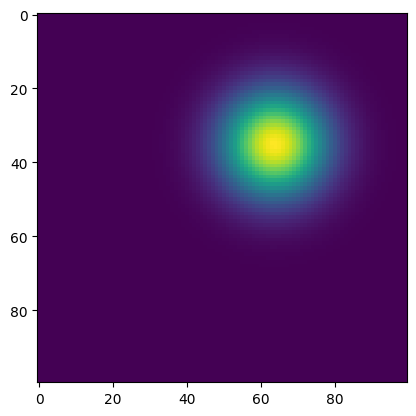

In [5]:
fig, ax = plt.subplots()

f = space_gaussian(X, Y, 7, params)
print(np.max(f))

ax.imshow(f, cmap='viridis', vmin=0, vmax=1)

Moving Gaussian with 4 parameters (x_i and y_i positions, t_i time and theta_i angle) is modelled.
* Newton's law of cooling for 

import